# Wine Price Prediction: mxbai Embeddings + CatBoost

## 基本情報

- 主題: CatBoost と Text Embedding の組み合わせ
- 作成者: 荒田禎之
- 位置づけ: Text embedding を追加したモデルの拡張
- 使用データ: Wine Review
- 分析課題: Wine Reviews データを使い、数値・カテゴリ変数・テキストから $\log(\mathrm{price})$ を CatBoost で予測
- 到達目標: 
  - Text Embedding に変換して、CatBoost モデルに追加する
  - 効果が無く、むしろ embedding 追加によってわずかに悪化する理由を理解する

This notebook includes code and explanations generated with OpenAI Codex.

---

## 1. 今回の方針

`description` を `mixedbread-ai/mxbai-embed-large-v1` で32次元のMatryoshka embeddingへ変換し、`points` およびカテゴリ変数とともに CatBoost へ入力して $\log(\mathrm{price})$ を予測します。encoder はfine-tuningせず、固定した特徴抽出器としてのみ使用します。

CatBoostが未導入の実行環境を想定し、`pip` でパッケージをインストールする。すでに必要なバージョンが導入されている場合は再利用または更新される。このセルの出力にはインストール状況が表示され、モデル学習そのものはまだ行わない。


In [1]:
!pip install -q -U catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


### ライブラリと乱数シードを準備するコード

ファイル操作、表形式データ処理、可視化、GPU確認、文章embedding生成、CatBoost回帰、データ分割、評価に必要なライブラリを読み込む。`SentenceTransformer` はレビュー本文のベクトル化、`torch` はGPUの利用可否確認に使用する。乱数シードを42に固定し、サンプリングや分割の再現性を確保する。


In [2]:
# 必要なライブラリが未インストールの場合のみ、次の行のコメントを外してください。
# %pip install -q -U sentence-transformers catboost scikit-learn

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from catboost import CatBoostRegressor
from sentence_transformers import SentenceTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
SEED = 42

## 1. データの読み込みと重複除外

`wine_review_CatBoost.ipynb` と同じ条件にするため、`title` と `description` の組が重複する行を除外します。価格が欠損または非正の行も除外します。

### 実行コードの説明

使用する数値列とカテゴリ列を定義し、必要な列だけCSVから読み込む。`title` と `description` の組が同じレビューを除外した後、本文と正の価格がある行だけを残す。カテゴリ欠損は `__MISSING__` として保持し、読み込み元、重複削除数、最終行数、先頭行を表示する。


In [ ]:
filename = "winemag-data-130k-v2.csv"
candidate_paths = [Path("data") / filename, Path("../data") / filename]
csv_path = next((path for path in candidate_paths if path.exists()), None)

if csv_path is None:
    searched = "\n".join(f"- {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(f"CSV が見つかりません。以下を確認してください。\n{searched}")

numeric_features = ["points"]
categorical_features = [
    "country",
    "designation",
    "province",
    "region_1",
    "region_2",
    "variety",
    "winery",
]
feature_source_columns = ["description", "price"] + numeric_features + categorical_features
read_columns = ["title"] + feature_source_columns

df = pd.read_csv(csv_path, usecols=read_columns)
rows_before = len(df)
df = df.drop_duplicates(subset=["title", "description"]).copy()
duplicates_removed = rows_before - len(df)

model_data = (
    df.loc[
        df["description"].notna()
        & df["price"].notna()
        & (df["price"] > 0),
        feature_source_columns,
    ]
    .reset_index(drop=True)
)

for column in categorical_features:
    model_data[column] = model_data[column].fillna("__MISSING__").astype(str)

print(f"Loaded: {csv_path.resolve()}")
print(f"Original rows: {rows_before:,}")
print(f"Removed duplicated reviews: {duplicates_removed:,}")
print(f"Rows used after deduplication and price filtering: {len(model_data):,}")
display(model_data.head())

## 2. mxbai-embed-large-v1 によるembedding生成

`SentenceTransformer.encode` は推論モードで実行されます。さらに全パラメータの勾配を無効化し、encoder が学習されないことを明示します。`truncate_dim=32` により、Matryoshka学習された表現を32次元で出力します。動作確認時は `MAX_ROWS` を指定できます。

### 実行コードの説明

`mixedbread-ai/mxbai-embed-large-v1` を読み込み、Matryoshka表現を32次元へ縮約する。GPUがあればCUDA、なければCPUを使用する。encoderを評価モードにし、全パラメータの勾配計算を無効化するためfine-tuningは発生しない。レビュー本文を64件ずつ処理し、L2正規化した32次元の `float32` embeddingを生成する。`MAX_ROWS` は動作確認時だけ対象行を減らすための設定である。


In [4]:
ENCODER_NAME = "mixedbread-ai/mxbai-embed-large-v1"
EMBEDDING_DIM = 32
BATCH_SIZE = 64
MAX_ROWS = None  # 例: 10_000。全データを使う場合は None

if MAX_ROWS is not None and len(model_data) > MAX_ROWS:
    model_data = model_data.sample(MAX_ROWS, random_state=SEED).reset_index(drop=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
encoder = SentenceTransformer(
    ENCODER_NAME,
    truncate_dim=EMBEDDING_DIM,
    device=device,
)
encoder.eval()
for parameter in encoder.parameters():
    parameter.requires_grad_(False)

print(f"Encoder device: {device}")
embeddings = encoder.encode(
    model_data["description"].tolist(),
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
).astype("float32")

print(f"Embedding shape: {embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/114k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Encoder device: cuda


Batches:   0%|          | 0/1744 [00:00<?, ?it/s]

Embedding shape: (111593, 32)


## 3. CatBoost用の特徴量作成

32個のembedding次元を数値列として追加します。目的変数には自然対数を取った価格を使用します。

### 実行コードの説明

32個のembedding次元に列名を付け、評価点とカテゴリ変数の表へ横方向に結合する。目的変数は価格の自然対数とする。結合後は不要になった中間データを削除してメモリを解放し、特徴量行列の大きさ、先頭列、log価格の要約統計を確認する。


In [ ]:
embedding_features = [f"embedding_{i:03d}" for i in range(embeddings.shape[1])]
embedding_frame = pd.DataFrame(embeddings, columns=embedding_features)

X = pd.concat(
    [
        model_data[numeric_features + categorical_features].reset_index(drop=True),
        embedding_frame,
    ],
    axis=1,
)
y = np.log(model_data["price"]).astype("float32")

del embedding_frame, embeddings

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]:,} columns")
display(X.iloc[:3, :12])
display(y.describe().rename("log_price").to_frame())

## 4. Train / validation / test分割

80%を訓練、10%を検証、10%を最終テストに使用します。encoder は固定済みなので、embedding生成を分割前に行っても目的変数の情報は混入しません。

### 実行コードの説明

特徴量と目的変数を80%の訓練、10%の検証、10%のテストへ固定乱数で分割する。訓練データはパラメータ推定、検証データはearly stoppingと最良iterationの選択、テストデータは最終性能の評価だけに使用する。各部分の件数も表示する。


In [6]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_holdout, y_holdout, test_size=0.5, random_state=SEED
)

print(f"Train: {len(X_train):,}, validation: {len(X_valid):,}, test: {len(X_test):,}")

Train: 89,274, validation: 11,159, test: 11,160


## 5. CatBoostの学習

GPUが利用可能な場合はCatBoostもGPUで学習します。検証RMSEに基づくearly stoppingを使用します。

### 実行コードの説明

利用可能な計算環境に応じてCatBoostをGPUまたはCPUで動かす。最大2,000 iteration、学習率0.05、深さ8、L2正則化5で回帰モデルを学習し、カテゴリ列は `cat_features` で直接指定する。検証RMSEが100 iteration改善しなければ停止し、検証性能が最良だったモデルを残す。


In [7]:
task_type = "GPU" if torch.cuda.is_available() else "CPU"
model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=2_000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=5.0,
    random_seed=SEED,
    task_type=task_type,
    allow_writing_files=False,
    verbose=100,
)

print(f"CatBoost task type: {task_type}")
model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=100,
    use_best_model=True,
)

print(f"Best iteration: {model.get_best_iteration():,}")

CatBoost task type: GPU
0:	learn: 0.6404436	test: 0.6395979	best: 0.6395979 (0)	total: 31.2ms	remaining: 1m 2s
100:	learn: 0.3568269	test: 0.3428116	best: 0.3428116 (100)	total: 2.4s	remaining: 45.2s
200:	learn: 0.3444751	test: 0.3330352	best: 0.3330352 (200)	total: 4.88s	remaining: 43.7s
300:	learn: 0.3374461	test: 0.3291563	best: 0.3291563 (300)	total: 8.21s	remaining: 46.3s
400:	learn: 0.3316631	test: 0.3265172	best: 0.3265172 (400)	total: 11.5s	remaining: 45.9s
500:	learn: 0.3264360	test: 0.3243607	best: 0.3243607 (500)	total: 14s	remaining: 41.9s
600:	learn: 0.3217034	test: 0.3226725	best: 0.3226725 (600)	total: 16.6s	remaining: 38.6s
700:	learn: 0.3174601	test: 0.3214685	best: 0.3214572 (699)	total: 19.1s	remaining: 35.4s
800:	learn: 0.3134561	test: 0.3207355	best: 0.3207328 (799)	total: 23.2s	remaining: 34.8s
900:	learn: 0.3097089	test: 0.3199568	best: 0.3199568 (900)	total: 25.8s	remaining: 31.5s
1000:	learn: 0.3061852	test: 0.3194723	best: 0.3194547 (995)	total: 28.4s	remainin

## 6. テストデータでの評価

### 実行コードの説明

最終テストデータのlog価格を予測し、RMSE、MAE、$R^2$ を計算する。RMSEは大きな誤差を強く評価し、MAEは平均的な絶対誤差、$R^2$ はlog価格の変動を説明できた割合を表す。さらに指数変換でドル価格へ戻し、価格単位のMAEを算出する。


In [8]:
y_pred = model.predict(X_test)
metrics = pd.Series({
    "RMSE (log price)": mean_squared_error(y_test, y_pred) ** 0.5,
    "MAE (log price)": mean_absolute_error(y_test, y_pred),
    "R2 (log price)": r2_score(y_test, y_pred),
    "MAE (price, USD)": mean_absolute_error(np.exp(y_test), np.exp(y_pred)),
})
display(metrics.to_frame("value"))

,value
RMSE (log price),0.320327
MAE (log price),0.238071
R2 (log price),0.768982
"MAE (price, USD)",10.059086


### 予測値と残差を可視化するコード

左図では実際のlog価格と予測log価格を比較し、45度の破線からの距離を予測誤差として確認する。右図では残差を「実際値 − 予測値」として表示する。0を中心に対称なら系統的な偏りが小さく、中心のずれや長い裾があれば過大・過小予測や外れた事例が存在する。


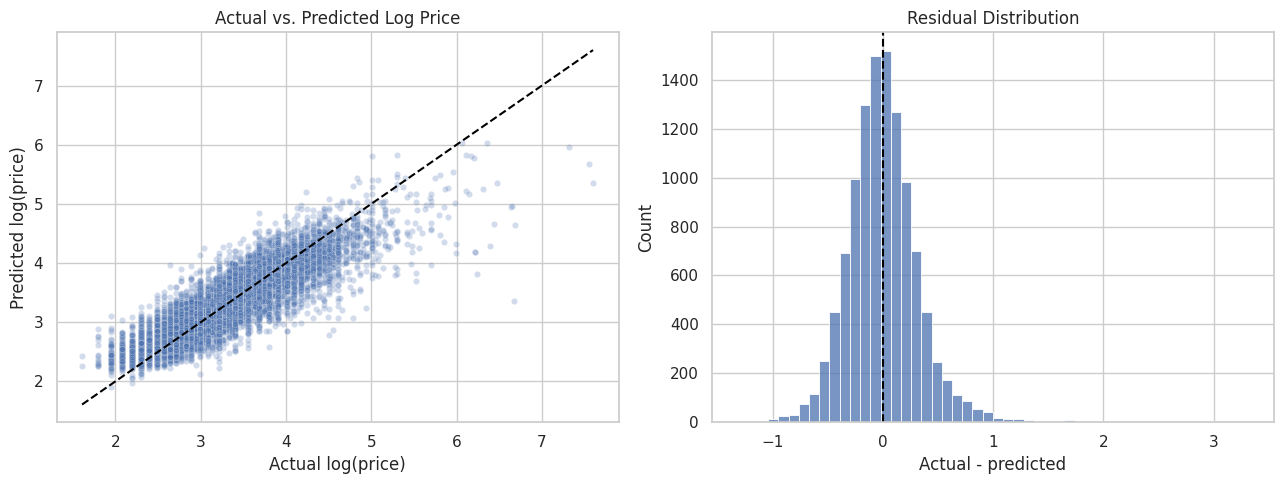

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.25, s=20, ax=axes[0])
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(
    title="Actual vs. Predicted Log Price",
    xlabel="Actual log(price)",
    ylabel="Predicted log(price)",
)

residuals = y_test - y_pred
sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set(title="Residual Distribution", xlabel="Actual - predicted")

plt.tight_layout()
plt.show()

## 7. 特徴量重要度

個々のembedding次元には直接的な意味を付けにくいため、32次元の重要度を合計して `description_embedding` として表示します。

### 実行コードの説明

CatBoostが返す全特徴量の重要度を列名と対応付ける。個々のembedding次元は意味を直接解釈しにくいため、32次元分を合計して `description_embedding` という1グループにまとめる。評価点やカテゴリ変数と並べて表・横棒グラフで比較し、レビュー本文全体が予測へどの程度利用されたかを確認する。


,importance
description_embedding,29.448717
points,20.181209
region_1,14.728680
variety,9.301710
winery,8.533104
country,5.897515
designation,5.228445
province,3.781227
region_2,2.899392


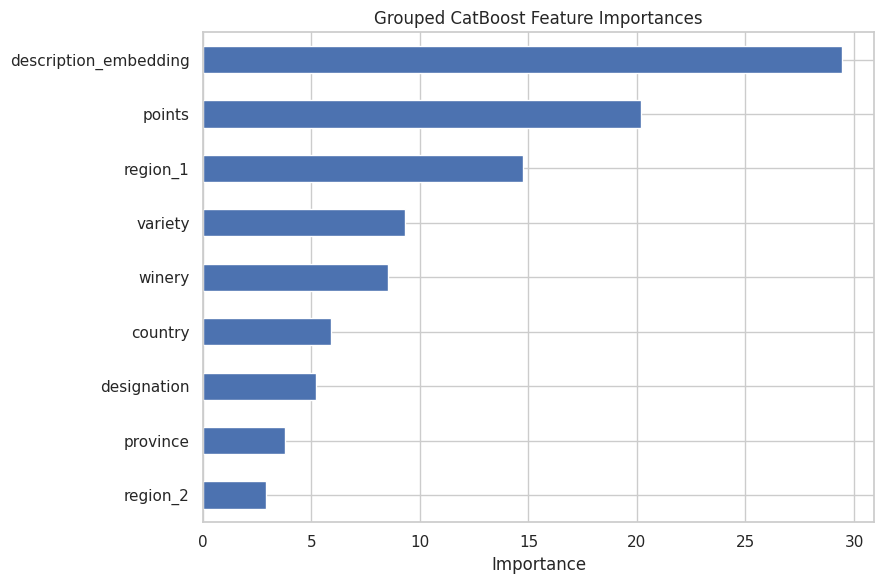

In [10]:
raw_importance = pd.Series(
    model.get_feature_importance(),
    index=X.columns,
    name="importance",
)
grouped_importance = pd.concat([
    raw_importance[numeric_features + categorical_features],
    pd.Series({
        "description_embedding": raw_importance[embedding_features].sum(),
    }),
]).sort_values(ascending=False)

display(grouped_importance.rename("importance").to_frame())

plt.figure(figsize=(9, 6))
grouped_importance.sort_values().plot.barh()
plt.title("Grouped CatBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. 予測結果の例

### 実行コードの説明

テストデータの先頭10件を取り出し、表示用には元の数値・カテゴリ変数だけを残す。実際の価格とモデル予測を指数変換してドル単位で追加することで、embedding自体を表示せず、個別ワインの入力情報と価格誤差を読みやすい形で確認する。


In [ ]:
example_columns = numeric_features + categorical_features
prediction_examples = X_test.loc[:, example_columns].head(10).copy()
prediction_examples["actual_price"] = np.exp(y_test.head(10))
prediction_examples["predicted_price"] = np.exp(model.predict(X_test.head(10)))
display(prediction_examples)

## 注意点

embedding生成はfine-tuningではなく固定encoderによる前処理です。32次元へ縮約しても、全データのembedding生成には相応のGPU時間が必要です。比較実験では、同じデータ分割を使った `wine_review_CatBoost.ipynb` の結果とRMSE・MAE・$R^2$ を比較してください。